In [3]:
# MUH FIKAL ANSARI_241061011
#soal nomor 1
import pandas as pd

data = {
    'Y': [71.28, 73.8, 70.25, 73.64, 75.11, 73.01, 68.95, 71.13, 84.85, 80.77, 80.36, 73.23],
    'X1': [0,1,0,0,1,0,0,0,1,1,1,1],
    'X2': [12.53,13.62,13,13.43,13.87,13.7,12.12,12.69,15.61,15.12,14.54,13.41],
    'X3': [56.9,71.4,71.43,74.53,79.24,68.96,70.64,65.24,71.19,84.45,71.53,70.57],
    'X4': [71.11,69.55,67.85,68.84,71.34,70.89,66.99,69.04,72.6,71.39,71.78,71]
}

df = pd.DataFrame(data)
df

,Y,X1,X2,X3,X4
0,71.28,0,12.53,56.90,71.11
1,73.80,1,13.62,71.40,69.55
2,70.25,0,13.00,71.43,67.85
3,73.64,0,13.43,74.53,68.84
4,75.11,1,13.87,79.24,71.34
5,73.01,0,13.70,68.96,70.89
6,68.95,0,12.12,70.64,66.99
7,71.13,0,12.69,65.24,69.04
8,84.85,1,15.61,71.19,72.60
9,80.77,1,15.12,84.45,71.39


In [6]:
#2
import statsmodels.api as sm

X = df[['X1','X2','X3','X4']]
Y = df['Y']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     36.07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        01:53:18   Log-Likelihood:                -16.957
No. Observations:                  12   AIC:                             43.91
Df Residuals:                       7   BIC:                             46.34
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.9539     30.443      0.918      0.3

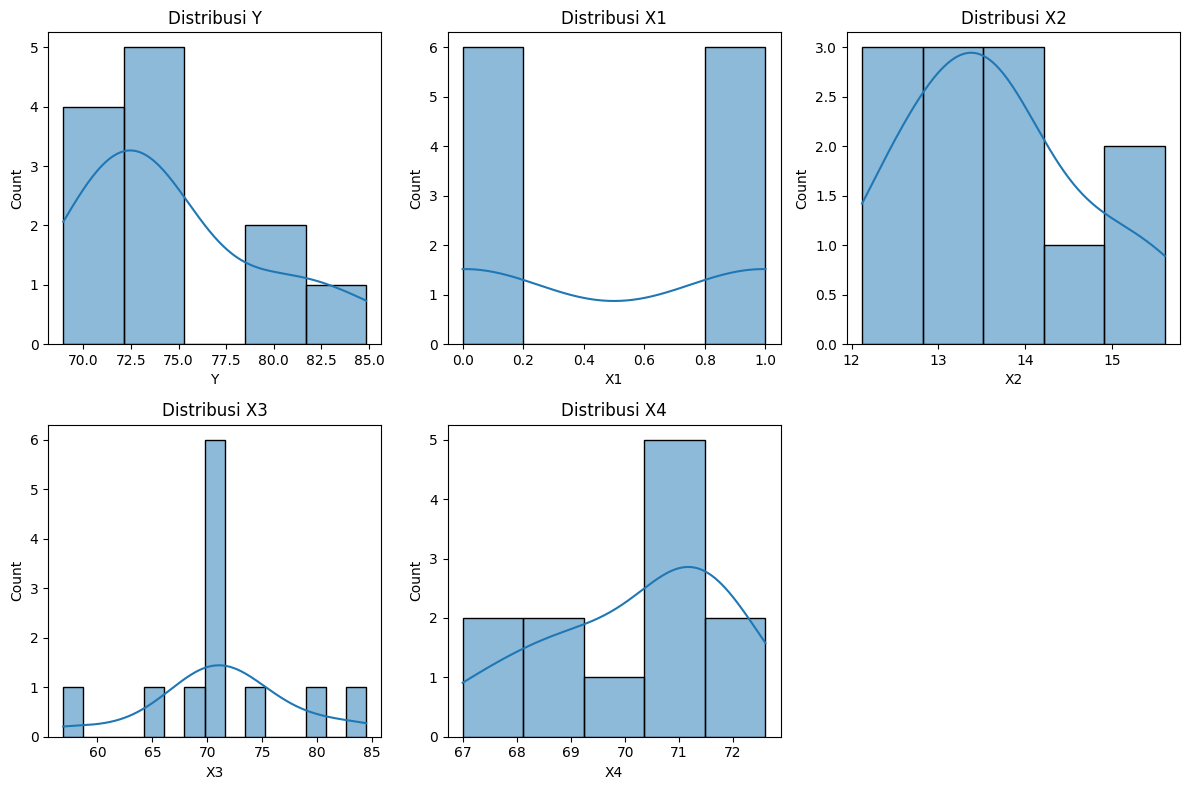

In [13]:
#3
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i, col in enumerate(df.columns):
    plt.subplot(2,3,i+1)  # 2 baris, 3 kolom
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

In [9]:
#4
from scipy import stats

params = {}

for col in df.columns:
    mu, sigma = stats.norm.fit(df[col])
    params[col] = (mu, sigma)
    print(f'{col}: mean={mu:.2f}, std={sigma:.2f}')

Y: mean=74.70, std=4.62
X1: mean=0.50, std=0.50
X2: mean=13.64, std=1.00
X3: mean=71.34, std=6.44
X4: mean=70.20, std=1.64


In [10]:
#5
import numpy as np

sim_data = pd.DataFrame()

for col in df.columns:
    mu, sigma = params[col]
    sim_data[col] = np.random.normal(mu, sigma, 500)

sim_data.head()

,Y,X1,X2,X3,X4
0,81.220109,-0.105441,13.165273,71.737279,69.380397
1,74.213277,1.261427,13.976766,67.827421,70.548606
2,81.829841,1.041127,13.964472,70.213609,68.965023
3,74.582736,-0.209302,15.033646,71.237413,68.407179
4,74.899143,0.558297,13.763303,81.169831,68.944998


In [11]:
#6
X_sim = sim_data[['X1','X2','X3','X4']]
Y_sim = sim_data['Y']

X_sim = sm.add_constant(X_sim)

model_sim = sm.OLS(Y_sim, X_sim).fit()
print(model_sim.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.576
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.179
Time:                        02:05:43   Log-Likelihood:                -1424.4
No. Observations:                 500   AIC:                             2859.
Df Residuals:                     495   BIC:                             2880.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         90.0147      9.290      9.689      0.0

In [16]:
# Ambil ringkasan penting dari model asli
summary_asli = pd.DataFrame({
    'Variabel': model.params.index,
    'Koef_Asli': model.params.values,
    'Pvalue_Asli': model.pvalues.values
})

# Ambil ringkasan dari model simulasi
summary_sim = pd.DataFrame({
    'Variabel': model_sim.params.index,
    'Koef_Simulasi': model_sim.params.values,
    'Pvalue_Simulasi': model_sim.pvalues.values
})

# Gabungkan
perbandingan = pd.merge(summary_asli, summary_sim, on='Variabel')
perbandingan

,Variabel,Koef_Asli,Pvalue_Asli,Koef_Simulasi,Pvalue_Simulasi
0,const,27.953911,0.389032,90.014700,1.916765e-20
1,X1,0.812356,0.538017,-0.596858,1.251387e-01
2,X2,4.868357,0.000725,-0.205511,3.036960e-01
3,X3,-0.133418,0.209535,0.018483,5.478204e-01
4,X4,-0.150030,0.763829,-0.192595,1.087264e-01


Model regresi pada data simulasi menunjukkan pola yang mirip dengan data asli, terutama dari arah pengaruh variabel. Namun, terdapat perbedaan pada nilai koefisien dan signifikansi yang disebabkan oleh proses acak dalam simulasi. Nilai R-squared yang tidak jauh berbeda menunjukkan bahwa model simulasi cukup mampu merepresentasikan data asli. Secara umum, simulasi dapat mendekati pola data, meskipun tidak identik dengan data sebenarnya.